## Task 1

In [1]:
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("salary.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
X= df[['YearsExperience']]
y= df['Salary']
model = LinearRegression()
model.fit(X,y)
df['predicted'] = model.predict(X)



## Task 2 Compute residuals

In [4]:
df['residuals'] = y - df['predicted']
df.head()


,Unnamed: 0,YearsExperience,Salary,predicted,residuals
0,0,1.2,39344.0,36188.158752,3155.841248
1,1,1.4,46206.0,38078.151217,8127.848783
2,2,1.6,37732.0,39968.143681,-2236.143681
3,3,2.1,43526.0,44693.124842,-1167.124842
4,4,2.3,39892.0,46583.117306,-6691.117306


When the residual is positive the model underpredicted. When it is negative then the model overpredicted

## Task 3: Compute MAE by Hand

In [5]:
df['abs_residual'] = df['residuals'].abs()
mae = df['abs_residual'].mean()
print(f"On average, the model's salary predictions are off by $ {mae}")

On average, the model's salary predictions are off by $ 4644.201289443538


## Task 4 Verify with SKlearn

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_sk = mean_absolute_error(y, df['predicted'])
print(mae_sk)


4644.201289443538


In [7]:
import numpy as np
# RMSE
RMSE_sk = np.sqrt(mean_squared_error(y, df['predicted']))
print(RMSE_sk)

5592.043608760663


RMSE is larger because it weighs larger errors more. 

## Task 5 Computer R-squared

In [8]:
r2= r2_score(y, df['predicted'])
print(r2)

0.9569566641435086


R2 of 1 means the model can explain 100% of the variation in the dependent variables  
R2 of 0 means the model explains 0% of the variation.  
The R2 value of .95 means that 95% of the variation in the salary can be explained by the model.  


## Task 6 Write a Manager Summary 

The salary prediction model has an average error of $4644.20.  
One of our metrics indicates that there are a few large errors in the data.  
Despite the model being pulled by a few of those data points, it has great potential to improve to accuracy of salary estimations.  
I would recommend moving forward with this model based on the calculated metrics because it is a powerful model with the potential to enhance productivity.  



## Task 7 Compare to a Second Model  

In [9]:
tree = DecisionTreeRegressor()
tree.fit(X,y)
y_pred = tree.predict(X)

In [10]:
mae_t = mean_absolute_error(y, y_pred)
rmse_t= np.sqrt(mean_squared_error(y,y_pred))
r2_t= r2_score(y,y_pred)

print(f"{'Metric':<8} {'Linear Reg':>12} {'Decision Tree':>15}")
print("-" * 38)
print(f"{'MAE':<8} {mae_sk:>12,.2f} {mae_t:>15,.2f}")
print(f"{'RMSE':<8} {RMSE_sk:>12,.2f} {rmse_t:>15,.2f}")
print(f"{'R2':<8} {r2:>12.4f} {r2_t:>15.4f}")

Metric     Linear Reg   Decision Tree
--------------------------------------
MAE          4,644.20          372.10
RMSE         5,592.04        1,299.70
R2             0.9570          0.9977


We prefer the decision tree based on the results of the statistical evaluation. For example, the R2 is greater meaning that more of the variation can be explained by this model.  
Also the MAE and RMSE are lower indicating that there is less error  
A decision tree may be overfitted because the R2 value is too close to 1.  
Without the train/test split the decision tree is given all the answers and may not perform well when given new data. 

## Task 8 Visualize the Residuals

Text(0, 0.5, 'Residual Error ($)')

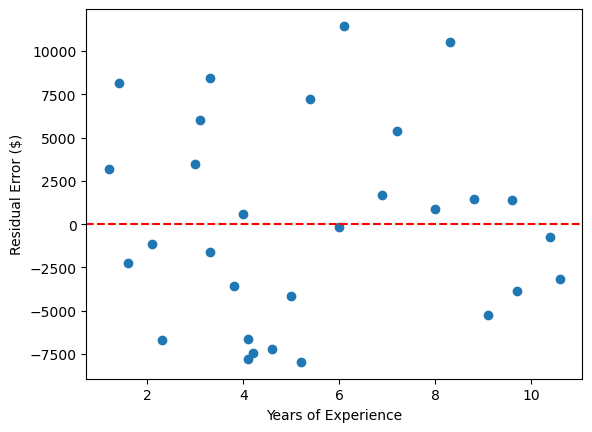

In [13]:
plt.scatter(df['YearsExperience'], df['residuals'])
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Years of Experience')
plt.ylabel('Residual Error ($)')

It looks like the errors are spread above and below 0 somewhat evenly.

If they were scattered randomly around 0, it means that the data that the model is plotting is a good fit for the model that is being used. If not, then there is something either missing from the data or from the model.

## Extra Credit

In [ ]:
def evaluate_regression(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted)**.5
    r2 = r2_score(actual, predicted)
    residual = abs(actual - predicted)
    largest = residual.max()
    return f"Mean Absolute Error: {mae} | Root Mean Squared Error: {rmse} | R2: {r2} | Largest Residual: {largest}"

'''
This function takes the
'''

'\nThis function takes the\n'

In [24]:
insurance = pd.read_csv('insurance.csv')
ins_X = insurance[['age', 'bmi']]
ins_y = insurance['charges']
ins_model = LinearRegression()
ins_model.fit(ins_X, ins_y)
pred = ins_model.predict(ins_X)
print(evaluate_regression(ins_y, pred))


Mean Absolute Error: 9032.478003391376 | Root Mean Squared Error: 11374.110466839007 | R2: 0.11718338606939949 | Largest Residual: 48021.97253956679
